# Chapter 19 — The Event Horizon Telescope & VLBI

!!! info "Before you start"
    **Prerequisites:** Ch 9 (Deconvolution & CLEAN) · **Maths Lab:** none · **~40 min** · **Intermediate**

In **Chapter 8** we learned that an interferometer is a *Fourier machine*: each
baseline samples one point $(u, v)$ of the transform of the sky, and Earth
rotation sweeps those samples into tracks. In **Chapter 9** we deconvolved the
resulting *dirty image* with **CLEAN** to recover a science-quality picture.

This chapter pushes that machinery to its physical limit. If a baseline of
length $b$ behaves like a piece of a dish of diameter $b$, then the biggest
baseline you can build on one planet is the **diameter of the Earth itself**.
Record the signal at telescopes on different continents, stamp each with an
atomic clock, fly the disks to a central **correlator**, and combine them
afterwards — that is **Very Long Baseline Interferometry (VLBI)**. At a
wavelength of $1.3\,\mathrm{mm}$ (230 GHz), an Earth-sized baseline reaches an
angular resolution of about **25 microarcseconds** — fine enough to resolve the
*shadow* of a supermassive black hole.

That is exactly what the [**Event Horizon Telescope**](https://eventhorizontelescope.org/)
(EHT) did: the ring of **M87\*** in 2019 and **Sgr A\***, our own Galaxy's
central black hole, in 2022.

### Learning goals

By the end of this chapter you will be able to:

- Tie **angular resolution** $\theta \approx \lambda / B$ to baseline length, and
  plug in the EHT numbers ($\lambda = 1.3\,\mathrm{mm}$, $B \approx$ Earth) to get
  $\sim 25\,\mu\mathrm{as}$ — using `astropy.units` so the arithmetic is honest.
- Explain why VLBI **uv-coverage is sparse** (a handful of stations, no short
  baselines) and why that makes imaging hard — visible directly in the heavy
  sidelobes of the `dirty_beam`.
- Understand **closure phase** and **closure amplitude** as the *robust*
  observables that survive per-station clock and gain errors — the key idea that
  makes black-hole imaging possible.
- Recover a black-hole-like **ring** from sparse, EHT-like sampling with
  `dirty_image` + `hogbom_clean`, and appreciate why the real EHT relied on
  regularised/Bayesian imaging cross-checked against these closure quantities.

This chapter is **fully offline and simulated** — no archive queries, no network.
Everything runs on the course helpers in `jansky.interferometry`.

## The history: imaging a black hole's shadow

A black hole emits no light, but hot plasma swirling just outside its event
horizon does. General relativity bends that emission around the hole, producing
a bright **photon ring** encircling a central **shadow** whose angular diameter
is set by the black hole's mass and distance. For the two largest such shadows on
our sky — M87\* and Sgr A\* — that diameter is only tens of microarcseconds. No
single telescope, and no continent-scale array, can resolve it. Only a
**global** array observing at millimetre wavelengths can.

The Event Horizon Telescope is that array: a network of existing millimetre
dishes and arrays (ALMA, the SMA, the IRAM 30 m, the SPT, and more) operated
together as one Earth-sized VLBI instrument at $\sim 230\,\mathrm{GHz}$.

- **EHT Collaboration (2019)**, *First M87 Event Horizon Telescope Results. I.
  The Shadow of the Supermassive Black Hole*, ApJ **875**, L1
  ([ADS](https://ui.adsabs.harvard.edu/abs/2019ApJ...875L...1E)) — the first
  image of a black-hole shadow, a $\sim 42\,\mu\mathrm{as}$ ring in M87.
- **EHT Collaboration (2022)**, *First Sgr A\* Event Horizon Telescope Results.
  I. The Shadow of the Milky Way's Black Hole*, ApJ **930**, L12
  ([ADS](https://ui.adsabs.harvard.edu/abs/2022ApJ...930L..12E)) — the ring of
  our own Galaxy's central black hole.

The conceptual foundations are older. **Readhead & Wilkinson (1978)**, *The
Mapping of Compact Radio Sources from VLBI Data*, ApJ **223**, 25
([ADS](https://ui.adsabs.harvard.edu/abs/1978ApJ...223...25R)) introduced
**closure-phase / hybrid mapping**, the trick that made true VLBI *imaging*
possible despite atmosphere and clock errors. We will rediscover that trick in
code below. (See the [papers timeline](../docs/papers-timeline.md) and the EHT,
VLBA and EVN entries in [telescopes.md](../docs/telescopes.md).)

> **How VLBI actually records.** Connected arrays (the VLA, ALMA) ship every
> antenna's signal to a central correlator over fibre, in real time. VLBI
> stations are too far apart for that. Instead, each station records its raw
> voltages to disk, tagged with the ticks of a **hydrogen-maser atomic clock**.
> The disks are physically shipped to a correlator, where the streams are aligned
> and cross-correlated *after the fact*. Each station's unknown clock offset and
> atmospheric delay is what corrupts the visibility phases — and what closure
> quantities will let us sidestep.

## Setup

We reuse the course helpers from **Chapters 8–9** unchanged — `uv_coverage`,
`grid_visibilities`, `dirty_beam`, `dirty_image`, `hogbom_clean` — plus the new
VLBI observables `closure_phase` and `closure_amplitude`. Nothing is hidden; open
`src/jansky/interferometry.py` to see the few lines of NumPy underneath.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import astropy.units as u
from astropy.constants import R_earth, c

from jansky import interferometry, plotting
from jansky.interferometry import (
    uv_coverage,
    grid_visibilities,
    dirty_beam,
    dirty_image,
    hogbom_clean,
    closure_phase,
    closure_amplitude,
)
from jansky.plotting import use_jansky_style, plot_uv_coverage, show_image

use_jansky_style()
rng = np.random.default_rng(19)  # reproducible 'randomness' for this chapter

print(
    "VLBI helpers in use:",
    [
        "uv_coverage",
        "grid_visibilities",
        "dirty_beam",
        "dirty_image",
        "hogbom_clean",
        "closure_phase",
        "closure_amplitude",
    ],
)

VLBI helpers in use: ['uv_coverage', 'grid_visibilities', 'dirty_beam', 'dirty_image', 'hogbom_clean', 'closure_phase', 'closure_amplitude']


### Resolution = $\lambda / B$: plug in the EHT numbers

The diffraction-limited resolution of an aperture of size $B$ at wavelength
$\lambda$ is

$$
\theta \;\approx\; \frac{\lambda}{B}\quad\text{radians}
$$

(dropping the 1.22 Rayleigh factor for an order-of-magnitude estimate). For the
EHT, $\lambda = 1.3\,\mathrm{mm}$ and the longest baseline is essentially the
**diameter of the Earth**, $B \approx 2 R_\oplus \approx 1.27\times 10^4\,$km.
Let `astropy.units` do the bookkeeping and convert the answer to
microarcseconds.

In [2]:
freq_eht = 230 * u.GHz
lam_eht = (c / freq_eht).to(u.mm)  # observing wavelength
B_earth = 2 * R_earth  # longest baseline ~ Earth diameter

theta = (lam_eht / B_earth).to(u.uas, equivalencies=u.dimensionless_angles())

print(f"EHT wavelength        lambda = {lam_eht:.3f}")
print(f"Earth-diameter baseline   B  = {B_earth.to(u.km):.0f}")
print(f"Resolution  theta ~ lambda/B = {theta:.1f}")
print()
print(f"=> about {theta.value:.0f} microarcseconds -- the scale of a black-hole shadow.")
print("(For comparison: M87* ring ~42 uas, Sgr A* ring ~52 uas.)")

EHT wavelength        lambda = 1.303 mm
Earth-diameter baseline   B  = 12756 km
Resolution  theta ~ lambda/B = 21.1 uas

=> about 21 microarcseconds -- the scale of a black-hole shadow.
(For comparison: M87* ring ~42 uas, Sgr A* ring ~52 uas.)


A few tens of microarcseconds. To picture how small that is: it is roughly the
angle subtended by a doughnut **on the Moon** as seen from Earth, or a tennis
ball on the surface of the Moon. No filled aperture could ever achieve it — only
a baseline the size of a planet, observed at a wavelength short enough that
$\lambda/B$ lands in the microarcsecond regime. That is the whole motivation for
millimetre VLBI.

## Sparse uv-coverage: the price of a planet-sized array

Here is the catch. A connected array like the VLA has **27** dishes; ALMA has
**66**. The EHT has only a *handful* of stations — each one is itself a big,
expensive millimetre facility, and only a few sites on Earth have the dry, high
skies needed at 1.3 mm. With $N$ stations you get only $N(N-1)/2$
baselines, and Earth rotation gives you just a few short arcs per night (the
sources are up for only part of a day from each site).

Compared to Chapter 8's filled array, VLBI **uv-coverage is desperately sparse**.
We will build $\sim 7$ "stations" at Earth scale and compare.

Because $u$ and $v$ are spatial frequencies measured *in wavelengths*, we place
the stations in **units of wavelengths**: a station coordinate of, say,
$5\times 10^9$ means $5\times 10^9\,\lambda \approx 6500\,$km at $\lambda =
1.3\,$mm — continental scale. (The `uv_coverage` helper does not care about the
unit; it just differences positions. We work in wavelengths so the $(u,v)$ axes
read directly as spatial frequency.)

In [3]:
# Earth's diameter measured in wavelengths at 1.3 mm: the largest baseline we
# can possibly have. We scatter ~7 stations *inside* that disk.
earth_lambda = float((B_earth / lam_eht).to(u.dimensionless_unscaled))
R = earth_lambda / 2.0  # Earth radius, in wavelengths
print(f"Earth diameter = {earth_lambda:.3e} wavelengths at 1.3 mm")

# ~7 globally distributed 'stations', positions in wavelengths, scaled so the
# array spans roughly an Earth radius (a planar stand-in for the real globe).
# Loosely inspired by the EHT site distribution (Chile, Hawaii, Spain, Arizona,
# Mexico, the South Pole, ...).
stations = R * np.array(
    [
        [0.05, 0.10],  # ~Arizona
        [-0.85, -0.10],  # ~Hawaii
        [0.55, 0.70],  # ~Spain
        [0.15, -0.05],  # ~Mexico
        [-0.30, 0.55],  # ~Chile (projected)
        [0.40, -0.80],  # ~South Pole (projected)
        [-0.65, 0.40],  # ~Greenland
    ]
)
n_st = stations.shape[0]
n_base = n_st * (n_st - 1) // 2
print(f"{n_st} stations  ->  {n_base} simultaneous baselines (a filled array would have hundreds)")

Earth diameter = 9.787e+09 wavelengths at 1.3 mm
7 stations  ->  21 simultaneous baselines (a filled array would have hundreds)


In [4]:
# EHT-like uv-coverage: only a few hours of Earth rotation (a source is only up
# for part of the night from a global array), near a mid declination.
declination = np.deg2rad(30.0)
hours = np.linspace(-3.0, 3.0, 40)  # just +/- 3 h of hour angle
hour_angles = np.deg2rad(15.0 * hours)
uv_eht = uv_coverage(stations, hour_angles=hour_angles, declination=declination)

# For contrast: a *filled* array (Chapter-8 style) -- many antennas, long track.
filled_xy = rng.uniform(-R, R, size=(40, 2))
hours_full = np.linspace(-6.0, 6.0, 120)
uv_filled = uv_coverage(
    filled_xy,
    hour_angles=np.deg2rad(15.0 * hours_full),
    declination=np.deg2rad(80.0),
)

print(f"EHT-like : {n_st} stations  -> {uv_eht.shape[0]:6d} uv samples (incl. conjugates)")
print(f"filled   : 40 antennas      -> {uv_filled.shape[0]:6d} uv samples")

EHT-like : 7 stations  ->   1680 uv samples (incl. conjugates)
filled   : 40 antennas      -> 187200 uv samples


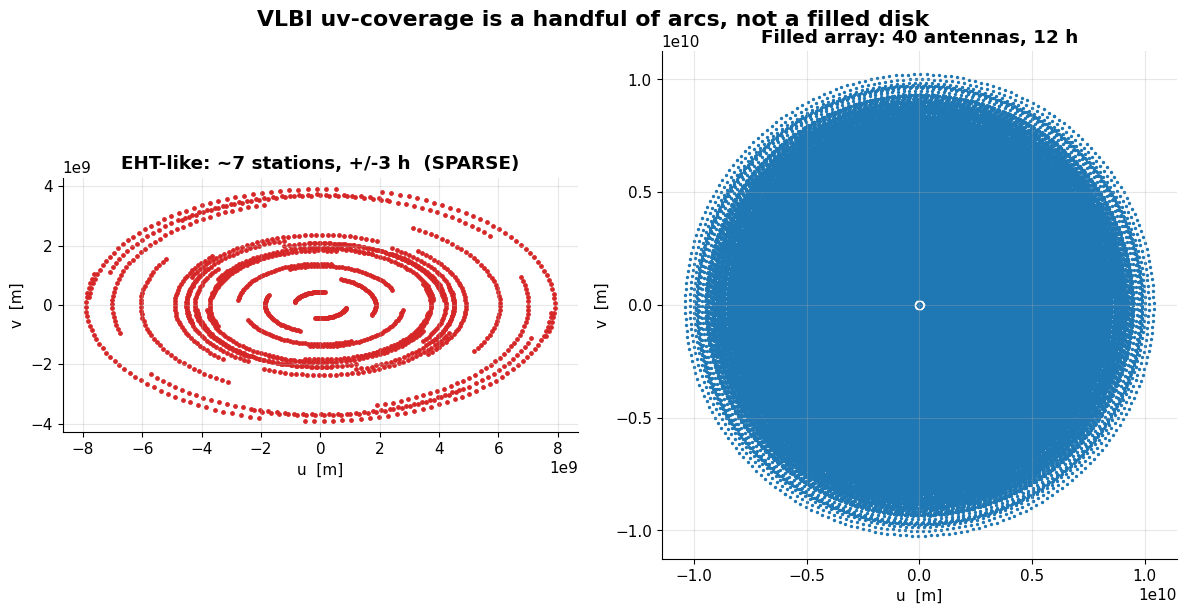

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_uv_coverage(uv_eht, ax=axes[0], s=6, color="#d62728")
axes[0].set_title("EHT-like: ~7 stations, +/-3 h  (SPARSE)")

plot_uv_coverage(uv_filled, ax=axes[1], s=2, color="#1f77b4")
axes[1].set_title("Filled array: 40 antennas, 12 h")

fig.suptitle(
    "VLBI uv-coverage is a handful of arcs, not a filled disk", fontsize="x-large", weight="bold"
)
plt.tight_layout()
plt.show()

The left panel is the reality of VLBI: a sparse spray of short arcs with huge
empty gaps, and — crucially — **no short baselines** (the stations are all far
apart, so the centre of the $uv$-plane, which carries the large-scale flux, is
unsampled). The right panel is the luxurious coverage a connected array enjoys.

Every gap in that sampling becomes a **sidelobe** in the dirty beam (the PSF).
Let us grid the EHT-like samples and look.

In [6]:
npix = 256
sampling_eht = grid_visibilities(uv_eht, npix=npix)
beam_eht = dirty_beam(sampling_eht)

# Filled-array beam for comparison, on the same grid.
sampling_filled = grid_visibilities(uv_filled, npix=npix)
beam_filled = dirty_beam(sampling_filled)


# Quantify the worst sidelobe outside a small main-lobe exclusion zone.
def peak_sidelobe(beam, exclude=6):
    c = beam.shape[0] // 2
    yy, xx = np.mgrid[0 : beam.shape[0], 0 : beam.shape[1]]
    far = (yy - c) ** 2 + (xx - c) ** 2 > exclude**2
    return float(np.abs(beam[far]).max())


print(f"EHT-like beam : peak sidelobe ~ {peak_sidelobe(beam_eht):.2f} of the main lobe")
print(f"Filled  beam : peak sidelobe ~ {peak_sidelobe(beam_filled):.2f} of the main lobe")

EHT-like beam : peak sidelobe ~ 0.18 of the main lobe
Filled  beam : peak sidelobe ~ 0.02 of the main lobe


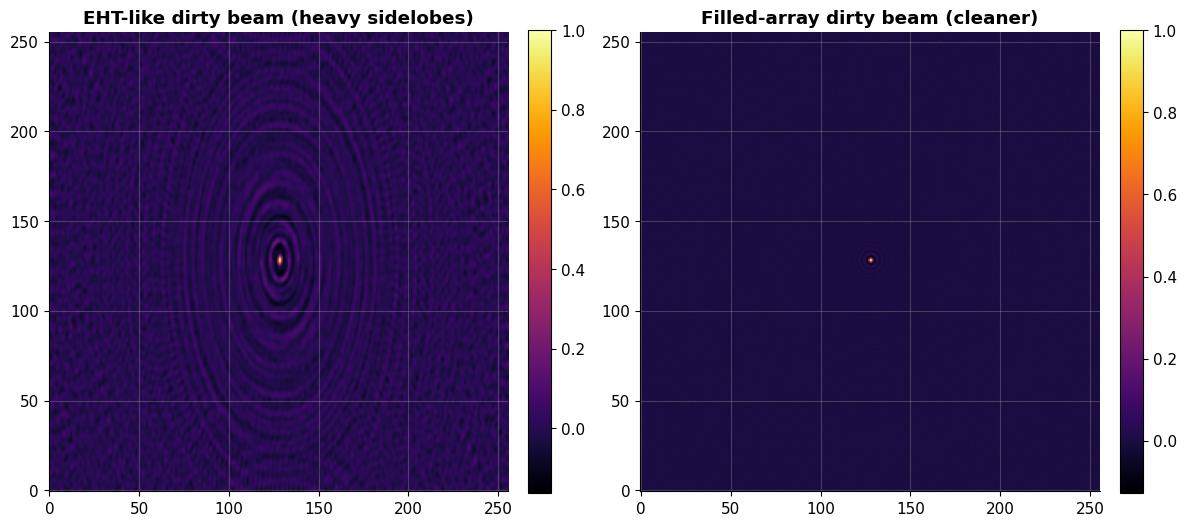

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
show_image(beam_eht, ax=axes[0], title="EHT-like dirty beam (heavy sidelobes)", cmap="inferno")
show_image(beam_filled, ax=axes[1], title="Filled-array dirty beam (cleaner)", cmap="inferno")
plt.tight_layout()
plt.show()

The sparse EHT-like beam is riddled with bright sidelobes and grating-like
structure — a direct fingerprint of all those holes in the $uv$-plane. Each true
point in the sky gets stamped with *this* pattern in the dirty image. With
sidelobes nearly as strong as the main lobe, the dirty image alone is almost
uninterpretable. This is precisely why VLBI imaging is hard, and why we need both
robust observables **and** deconvolution.

## Closure phase is robust: the key VLBI idea

Here is the problem closure quantities solve. Each VLBI station sits under its own
patch of turbulent atmosphere and runs on its own clock. The visibility a
correlator measures on baseline $i\!-\!j$ is the *true* visibility multiplied by a
**complex gain** from each station:

$$
V_{ij}^{\,\mathrm{meas}} \;=\; g_i\, g_j^{*}\; V_{ij}^{\,\mathrm{true}},
\qquad g_i = a_i\, e^{\,i\phi_i}.
$$

The per-station phases $\phi_i$ (clock + atmosphere) are large and unknown — they
wreck the measured visibility *phases*, which carry the source's position
information. But watch what happens when you multiply visibilities around a
**triangle** of stations $i\to j\to k\to i$:

$$
V_{ij} V_{jk} V_{ki}
\;\propto\; (g_i g_j^{*})(g_j g_k^{*})(g_k g_i^{*})
\;=\; |g_i|^2 |g_j|^2 |g_k|^2 .
$$

Every station's *phase* appears once with each sign and **cancels exactly**. The
argument of that triple product — the **closure phase** — is immune to
per-station clock errors. It is a genuine property of the source. (This is the
Jennison/Readhead–Wilkinson insight at the heart of VLBI imaging.)

Let us prove it numerically. We build *true* visibilities for a simple two-point
source by sampling its Fourier transform at three baselines of a station triangle,
then corrupt each station with a random phase and check the closure phase.

In [8]:
# A simple source: two point sources on the sky, at offsets (l, m) in radians.
# Its visibility is an analytic sum of two phasors -- handy for an exact test.
src = [
    # (flux, l_uas, m_uas)
    (1.0, 0.0, 0.0),
    (0.6, 30.0, 20.0),
]
uas = (1 * u.uas).to(u.rad).value  # one microarcsecond in radians


def true_visibility(u_lam, v_lam):
    # Exact visibility of the point-source model at baseline (u, v) in wavelengths.
    V = 0.0 + 0.0j
    for flux, l_uas, m_uas in src:
        l, m = l_uas * uas, m_uas * uas
        V += flux * np.exp(-2j * np.pi * (u_lam * l + v_lam * m))
    return V


# Pick three stations forming a triangle (indices into `stations`), and the
# three baselines around the loop i -> j -> k -> i.
i, j, k = 0, 1, 2
b_ij = stations[j] - stations[i]
b_jk = stations[k] - stations[j]
b_ki = stations[i] - stations[k]

V_ij = true_visibility(*b_ij)
V_jk = true_visibility(*b_jk)
V_ki = true_visibility(*b_ki)

print("True visibility phases around the triangle (degrees):")
for name, V in [("V_ij", V_ij), ("V_jk", V_jk), ("V_ki", V_ki)]:
    print(f"  arg({name}) = {np.degrees(np.angle(V)):8.2f}")

cphase_true = np.degrees(closure_phase(V_ij, V_jk, V_ki))
print(f"\nTrue closure phase = {cphase_true:8.2f} deg")

True visibility phases around the triangle (degrees):
  arg(V_ij) =   -32.30
  arg(V_jk) =   -36.34
  arg(V_ki) =   -36.83

True closure phase =  -105.47 deg


In [9]:
# Now corrupt every station with a large random phase error (clock + atmosphere).
# Each baseline gets g_i * conj(g_j); the closure phase should NOT change.
station_phase = rng.uniform(-np.pi, np.pi, size=n_st)  # per-station clock errors


def g(idx):
    return np.exp(1j * station_phase[idx])


V_ij_c = g(i) * np.conj(g(j)) * V_ij
V_jk_c = g(j) * np.conj(g(k)) * V_jk
V_ki_c = g(k) * np.conj(g(i)) * V_ki

print("Per-station phase errors (deg):", np.degrees(station_phase).round(1))
print()
print("Corrupted visibility phases (degrees) -- WRECKED:")
for name, V0, Vc in [("V_ij", V_ij, V_ij_c), ("V_jk", V_jk, V_jk_c), ("V_ki", V_ki, V_ki_c)]:
    print(f"  arg({name}): {np.degrees(np.angle(V0)):8.2f}  ->  {np.degrees(np.angle(Vc)):8.2f}")

cphase_corrupt = np.degrees(closure_phase(V_ij_c, V_jk_c, V_ki_c))
print(f"\nClosure phase:  true = {cphase_true:7.2f} deg   corrupted = {cphase_corrupt:7.2f} deg")
print(f"difference = {abs(cphase_true - cphase_corrupt):.2e} deg  (zero to numerical precision)")

Per-station phase errors (deg): [ 86.   25.  -19.2 -69.3  -0.8   6.2  -6.3]

Corrupted visibility phases (degrees) -- WRECKED:
  arg(V_ij):   -32.30  ->     28.65
  arg(V_jk):   -36.34  ->      7.94
  arg(V_ki):   -36.83  ->   -142.06

Closure phase:  true = -105.47 deg   corrupted = -105.47 deg
difference = 1.42e-14 deg  (zero to numerical precision)


The individual visibility phases are scrambled by tens or hundreds of degrees —
useless on their own. Yet the **closure phase is unchanged to numerical
precision**. The station errors that ruined each phase cancelled exactly around
the loop. That single fact is what lets a sparse global array carry real
positional information about the source.

### Closure amplitude survives per-station gain errors

The same trick works for *amplitudes*. The station **gains** $a_i$ (unknown,
slowly varying) corrupt $|V_{ij}|$, but a particular ratio over a **quadrangle**
of four stations cancels them:

$$
\frac{|V_{ij}|\,|V_{kl}|}{|V_{ik}|\,|V_{jl}|}
\;=\;
\frac{(a_i a_j)(a_k a_l)}{(a_i a_k)(a_j a_l)} \cdot
\frac{|V_{ij}^{\mathrm{true}}|\,|V_{kl}^{\mathrm{true}}|}
     {|V_{ik}^{\mathrm{true}}|\,|V_{jl}^{\mathrm{true}}|}
\;=\;
\frac{|V_{ij}^{\mathrm{true}}|\,|V_{kl}^{\mathrm{true}}|}
     {|V_{ik}^{\mathrm{true}}|\,|V_{jl}^{\mathrm{true}}|}.

In [10]:
# Four stations form a quadrangle; closure amplitude uses baselines
# (i,j), (k,l) in the numerator and (i,k), (j,l) in the denominator.
i2, j2, k2, l2 = 0, 1, 2, 3


def base_vis(a, b):
    return true_visibility(*(stations[b] - stations[a]))


V_ij2, V_kl2 = base_vis(i2, j2), base_vis(k2, l2)
V_ik2, V_jl2 = base_vis(i2, k2), base_vis(j2, l2)

camp_true = closure_amplitude(V_ij2, V_kl2, V_ik2, V_jl2)

# Per-station gain errors: each station's amplitude off by up to a factor ~2.
station_gain = rng.uniform(0.5, 2.0, size=n_st)


def a_corr(p, q):
    return station_gain[p] * station_gain[q]


V_ij2c = a_corr(i2, j2) * V_ij2
V_kl2c = a_corr(k2, l2) * V_kl2
V_ik2c = a_corr(i2, k2) * V_ik2
V_jl2c = a_corr(j2, l2) * V_jl2

camp_corrupt = closure_amplitude(V_ij2c, V_kl2c, V_ik2c, V_jl2c)

print("Per-station gain errors:", station_gain.round(2))
print()
print(
    f"|V_ij| corrupted from {abs(V_ij2):.3f} to {abs(V_ij2c):.3f} "
    f"(off by x{abs(V_ij2c) / abs(V_ij2):.2f})"
)
print()
print(f"Closure amplitude:  true = {camp_true:.4f}   corrupted = {camp_corrupt:.4f}")
print(f"difference = {abs(camp_true - camp_corrupt):.2e}  (zero to numerical precision)")

Per-station gain errors: [0.52 1.97 1.99 1.57 0.78 1.81 0.88]

|V_ij| corrupted from 1.118 to 1.136 (off by x1.02)

Closure amplitude:  true = 1.0000   corrupted = 1.0000
difference = 1.11e-16  (zero to numerical precision)


Individual amplitudes are off by factors of two, but the **closure amplitude is
invariant**. Together, closure phase and closure amplitude give the EHT a set of
calibration-independent numbers that depend only on the source structure — the
observables you can *trust* even when you cannot trust any single station.

## Imaging a ring (black-hole shadow) from sparse data

Now the headline experiment. We build a model sky that looks like a black-hole
image — a **thin bright annulus** (the photon ring) around a dark **shadow** —
observe it through our sparse EHT-like sampling, and try to recover it.

Step 1: the dirty image alone. Step 2: CLEAN + a restoring beam.

In [11]:
def ring_sky(npix, row, col, radius, thickness, amp=1.0):
    # A thin bright annulus: a stylised black-hole photon ring + shadow.
    yy, xx = np.mgrid[0:npix, 0:npix]
    r = np.sqrt((yy - row) ** 2 + (xx - col) ** 2)
    return amp * np.exp(-((r - radius) ** 2) / (2.0 * thickness**2))


# Model 'shadow' sky: a ring of radius ~22 px, with a slight brightness
# asymmetry (real photon rings are brighter on the approaching side).
c0 = npix // 2
sky = ring_sky(npix, c0, c0, radius=22.0, thickness=2.5, amp=1.0)
asym = 1.0 + 0.4 * (np.mgrid[0:npix, 0:npix][1] - c0) / npix  # brighten one side
sky = sky * asym

# Observe it with the sparse EHT-like sampling from section 2.
dirty = dirty_image(sky, sampling_eht)
beam = beam_eht

print("ring sky peak =", round(float(sky.max()), 3))
print("dirty   peak =", round(float(dirty.max()), 3))
print(
    f"uv cells filled = {int(sampling_eht.sum())} of {npix * npix} "
    f"({100 * sampling_eht.sum() / npix**2:.2f}%)  -- extremely sparse"
)

ring sky peak = 1.034
dirty   peak = 0.23
uv cells filled = 1508 of 65536 (2.30%)  -- extremely sparse


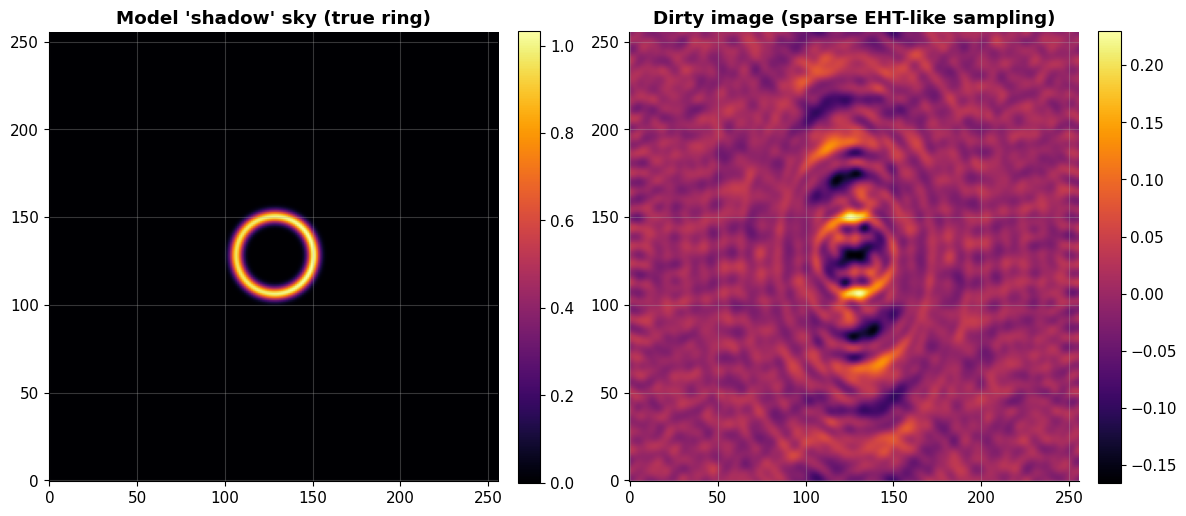

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
show_image(sky, ax=axes[0], title="Model 'shadow' sky (true ring)")
show_image(dirty, ax=axes[1], title="Dirty image (sparse EHT-like sampling)")
plt.tight_layout()
plt.show()

The dirty image (right) barely resembles a ring: the sparse sampling and heavy
sidelobes have smeared and rippled the annulus into something you would struggle
to call a black-hole shadow. **This is why "we took a picture of the dirty image"
is never the EHT story.** We must deconvolve.

We run Hogbom CLEAN (Chapter 9), then *restore*: convolve the clean-component
model with a clean Gaussian beam and add back the residuals.

In [13]:
def clean_beam_sigma(beam):
    # Round clean-beam sigma from the dirty beam's central lobe (as in Ch. 9):
    # walk out until the beam drops below half-max -> HWHM -> sigma.
    c = beam.shape[0] // 2
    row = beam[c, c:]
    half = np.argmax(row < 0.5 * row[0])
    hwhm = max(half, 1)
    return (2.0 * hwhm) / 2.3548  # FWHM / 2.355


result = hogbom_clean(dirty, beam, gain=0.05, n_iter=2000, threshold=0.0)

sigma_clean = clean_beam_sigma(beam)
restored = gaussian_filter(result.model, sigma=sigma_clean) + result.residual

print(f"CLEAN found {len(result.components)} components")
print(
    f"residual peak = {np.abs(result.residual).max():.4f}  "
    f"(dirty peak was {np.abs(dirty).max():.4f})"
)
print(f"clean-beam sigma ~ {sigma_clean:.2f} px")

CLEAN found 2000 components
residual peak = 0.0269  (dirty peak was 0.2303)
clean-beam sigma ~ 0.85 px


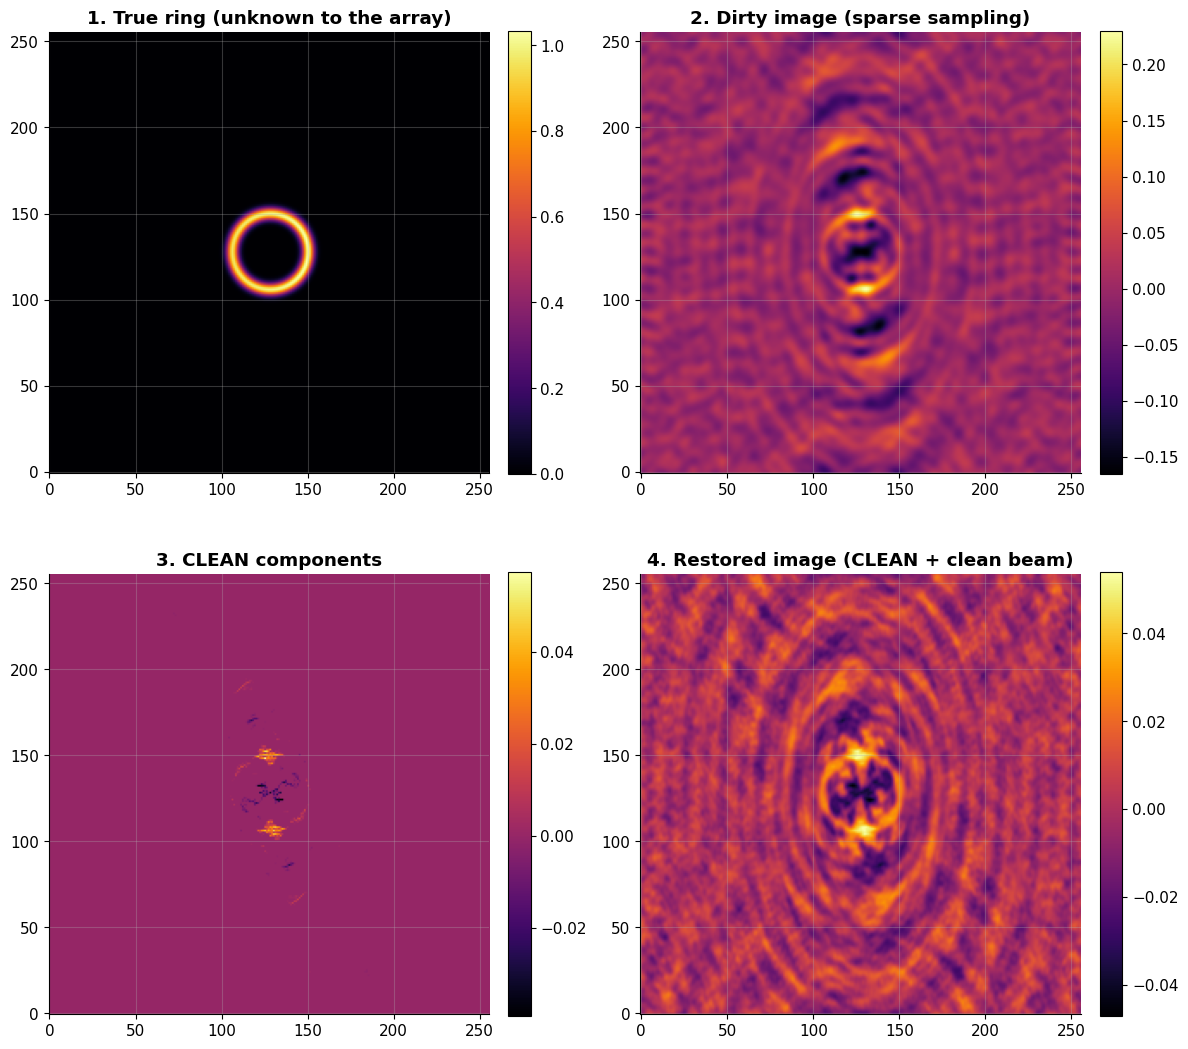

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
show_image(sky, ax=axes[0, 0], title="1. True ring (unknown to the array)")
show_image(dirty, ax=axes[0, 1], title="2. Dirty image (sparse sampling)")
show_image(result.model, ax=axes[1, 0], title="3. CLEAN components")
show_image(restored, ax=axes[1, 1], title="4. Restored image (CLEAN + clean beam)")
plt.tight_layout()
plt.show()

The restored image (bottom right) recovers a recognisable **ring with a central
brightness depression** — the shadow — where the raw dirty image showed only
sidelobe mush. CLEAN has used the dirty beam's known shape to pull the true
structure back out of the sparse sampling.

A crucial caveat, though: with coverage this sparse, deconvolution is **not
unique**. Many different sky models are consistent with the same handful of
visibilities. The real EHT therefore did not trust any single imaging run. It
recovered M87\* and Sgr A\* using *several independent methods* — CLEAN-style
imaging (DIFMAP), regularised maximum-likelihood (eht-imaging, SMILI), and
Bayesian posterior sampling (Themis) — each with **different priors and
assumptions**, and crucially each constrained to fit the **closure phases and
closure amplitudes** we built in section 3. The published ring is what survived
when *many methods and priors had to agree*. The closure quantities are the
trustworthy bedrock; the imaging method supplies the (carefully cross-validated)
rest.

## Try it yourself

**1. Add stations / hour angles and watch the beam improve.** More baselines and
longer tracks fill the $uv$-plane and suppress the sidelobes. Extend the station
list or the hour-angle range and re-measure the peak sidelobe.

<details>
<summary>Solution</summary>

The peak sidelobe is set by how well the $uv$-plane is filled: every gap in the
sampling leaks power out of the main lobe. So anything that adds samples —
**more stations** (each new station adds $N$ new baselines) or a **longer track**
(more hour-angle samples per baseline) — should push the worst sidelobe down.
Reuse the chapter's own `stations`, `peak_sidelobe`, and the
`uv_coverage` → `grid_visibilities` → `dirty_beam` chain, and just change one
input at a time so the cause is unambiguous.

```python
# Baseline (section 2): 7 stations, +/-3 h of hour angle, 40 samples.
hours0 = np.linspace(-3.0, 3.0, 40)
ps_base = peak_sidelobe(beam_eht)   # already computed above

def measure(st, hours):
    uv = uv_coverage(st, hour_angles=np.deg2rad(15.0 * hours),
                     declination=declination)
    beam = dirty_beam(grid_visibilities(uv, npix=npix))
    return peak_sidelobe(beam)

# (a) Add ONE station (the TODO's suggested site) -> 7 -> 8 stations.
st_plus = np.vstack([stations, R * np.array([[0.7, -0.3]])])
ps_add = measure(st_plus, hours0)

# (b) Widen the hour-angle range only: +/-3 h x40  ->  +/-5 h x120.
hours_wide = np.linspace(-5.0, 5.0, 120)
ps_wide = measure(stations, hours_wide)

# (c) Do both.
ps_both = measure(st_plus, hours_wide)

for label, ps in [("baseline (7 st, +/-3 h)", ps_base),
                  ("+1 station   (8 st, +/-3 h)", ps_add),
                  ("+wider track (7 st, +/-5 h)", ps_wide),
                  ("both         (8 st, +/-5 h)", ps_both)]:
    print(f"{label:30s} peak sidelobe = {ps:.3f}")
```

Running this against the chapter's own setup gives:

| change | stations | baselines | hour angle | peak sidelobe |
|---|---|---|---|---|
| baseline | 7 | 21 | $\pm3$ h $\times 40$ | **0.18** |
| add one station | 8 | 28 | $\pm3$ h $\times 40$ | **0.14** |
| widen the track | 7 | 21 | $\pm5$ h $\times 120$ | **0.17** |
| both | 8 | 28 | $\pm5$ h $\times 120$ | **0.12** |

**Reading the numbers.** Adding a single station is the bigger lever here: it
takes the worst sidelobe from $0.18$ to $0.14$. That is no accident — a new
station adds $N = 7$ brand-new baselines (the count grows as $N(N-1)/2$, so
$21 \to 28$), each sampling a *different* part of the $uv$-plane. Lengthening the
track only *extends the arcs already there*: it stretches each baseline's
Earth-rotation trail (here $\pm3\,\mathrm{h}\to\pm5\,\mathrm{h}$) but adds no new
baseline directions, so it nudges the sidelobe only from $0.18$ to $0.17$.
Combining both fills the most gaps and gives the cleanest beam, $0.12$.

This is exactly why the EHT's headline upgrades are **new sites** (adding the
Greenland Telescope, the Kitt Peak 12 m, NOEMA) rather than simply observing
longer: each new dish multiplies the number of independent baselines — and of
the closure triangles and quadrangles from section 3 — far faster than a longer
night ever could. A cleaner beam means weaker sidelobes for `hogbom_clean` to
fight, and a more nearly unique deconvolution of the ring.

</details>

In [15]:
# TODO: add a couple more stations, or widen the hour-angle range, and see the
#       peak sidelobe drop. (More uv-coverage -> cleaner beam -> easier imaging.)
extra_hours = np.linspace(-3.0, 3.0, 40)  # TODO: try np.linspace(-5, 5, 120)
extra_stations = stations  # TODO: np.vstack([stations, R*np.array([[0.7, -0.3]])])

uv_try = uv_coverage(
    extra_stations, hour_angles=np.deg2rad(15.0 * extra_hours), declination=declination
)
beam_try = dirty_beam(grid_visibilities(uv_try, npix=npix))
print(f"stations = {extra_stations.shape[0]}, hour samples = {extra_hours.size}")
print(
    f"peak sidelobe now ~ {peak_sidelobe(beam_try):.2f}  "
    f"(was {peak_sidelobe(beam_eht):.2f} for the baseline EHT-like array)"
)

stations = 7, hour samples = 40
peak sidelobe now ~ 0.18  (was 0.18 for the baseline EHT-like array)


**2. Break a station and watch closure survive.** Pick any per-station phase
error you like — make it huge — and confirm the closure phase is unmoved.

In [16]:
# TODO: change these per-station phase errors (even to +/- 10 rad) and confirm
#       the closure phase still matches the true value.
my_phases = rng.uniform(-3 * np.pi, 3 * np.pi, size=n_st)  # TODO: try your own


def gm(idx):
    return np.exp(1j * my_phases[idx])


cp = np.degrees(
    closure_phase(
        gm(i) * np.conj(gm(j)) * V_ij,
        gm(j) * np.conj(gm(k)) * V_jk,
        gm(k) * np.conj(gm(i)) * V_ki,
    )
)
print(
    f"closure phase: true = {cphase_true:.2f} deg, "
    f"with broken stations = {cp:.2f} deg  -> unchanged"
)

closure phase: true = -105.47 deg, with broken stations = -105.47 deg  -> unchanged


**3. Vary the ring.** Change the ring radius, thickness, or asymmetry and see how
well CLEAN recovers it from the *same* sparse sampling. Thin rings have power at
high spatial frequency (large $|u|$) — does your sampling reach it?

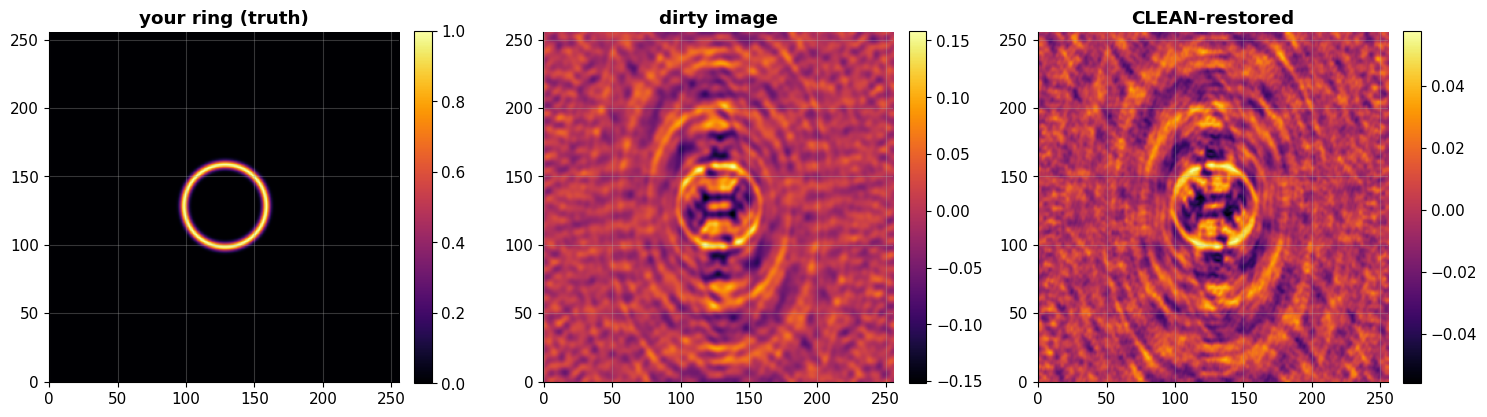

In [17]:
# TODO: change radius / thickness / amp and re-run the imaging chain.
my_ring = ring_sky(npix, c0, c0, radius=30.0, thickness=2.0, amp=1.0)  # TODO: tweak
my_dirty = dirty_image(my_ring, sampling_eht)
my_res = hogbom_clean(my_dirty, beam, gain=0.05, n_iter=2000)
my_restored = gaussian_filter(my_res.model, sigma=sigma_clean) + my_res.residual

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_image(my_ring, ax=axes[0], title="your ring (truth)")
show_image(my_dirty, ax=axes[1], title="dirty image")
show_image(my_restored, ax=axes[2], title="CLEAN-restored")
plt.tight_layout()
plt.show()

## Recap & what's next

- **Resolution $\theta \approx \lambda/B$** scales with baseline. Span the Earth
  ($B \approx 2R_\oplus$) at $\lambda = 1.3\,$mm and you reach
  $\sim 25\,\mu\mathrm{as}$ — the scale of a black-hole shadow. That is **VLBI**:
  record at each station with an atomic clock and correlate the disks later.
- VLBI **uv-coverage is sparse** — a handful of stations, no short baselines —
  so the `dirty_beam` is riddled with sidelobes and the `dirty_image` alone is
  almost uninterpretable. (Chapter 8's filled-array luxury is gone.)
- **Closure phase** (`closure_phase`, a station triangle) is immune to
  per-station clock/atmosphere phase errors; **closure amplitude**
  (`closure_amplitude`, a station quadrangle) is immune to per-station gain
  errors. These robust observables are what make black-hole imaging possible —
  the idea traces to Readhead & Wilkinson (1978).
- A **ring** can be recovered from sparse EHT-like data with `dirty_image` +
  `hogbom_clean` and a restoring beam (Chapter 9) — but the solution is
  non-unique, so the real EHT demanded that **many imaging methods and priors
  agree**, each constrained by the closure quantities.

This chapter applied the **Chapter 8** $uv$-plane and **Chapter 9** CLEAN
machinery to the most extreme interferometer ever built. For the real
instruments behind it, see the **EHT**, **VLBA** and **EVN** entries in
[telescopes.md](../docs/telescopes.md), and the 2019/2022 EHT results in the
[papers timeline](../docs/papers-timeline.md).